# Plotting heatmap of single frame as illustration of monolayer heights

In [1]:
import sys
import json
import imageio
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from cmcrameri import cm
from scipy.ndimage import gaussian_filter
from matplotlib_scalebar.scalebar import ScaleBar


sys.path.append("scripts/utils")
from Microscopes     import Holomonitor, Tomocube
from SegmentedCells  import SegmentedCells
from file_operations import *

data_path = "../../../../hdd_data/silja/Monolayers/"

In [13]:
n0 = Tomocube().n0

dataset = "MDCK_20250904_B1-1"
frame   = 10
measure = "disc"
param   = "h"

In [14]:
config = json.load(open(f"configs/{dataset}.json"))

### SET MICROSCOPE ###
if config['microscope'] == "holomonitor": microscope = Holomonitor()
elif config['microscope'] == "tomocube":  microscope = Tomocube()

h_im, n_im = load_set_of_frames(f"{data_path}height_fields/calibrated/{dataset}", frame, microscope)


In [23]:
if measure == "disc":
    cells = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")
    
    A_mean = 1/(cells.density[frame - config["cells"]["fmin"]] / 10**6)
    r_mean = np.sqrt(A_mean / np.pi)
    sigma  = microscope.rblur * r_mean / microscope.pix_to_um
    im_disc = gaussian_filter(h_im, sigma)

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20250904_B1-1_cells.p.


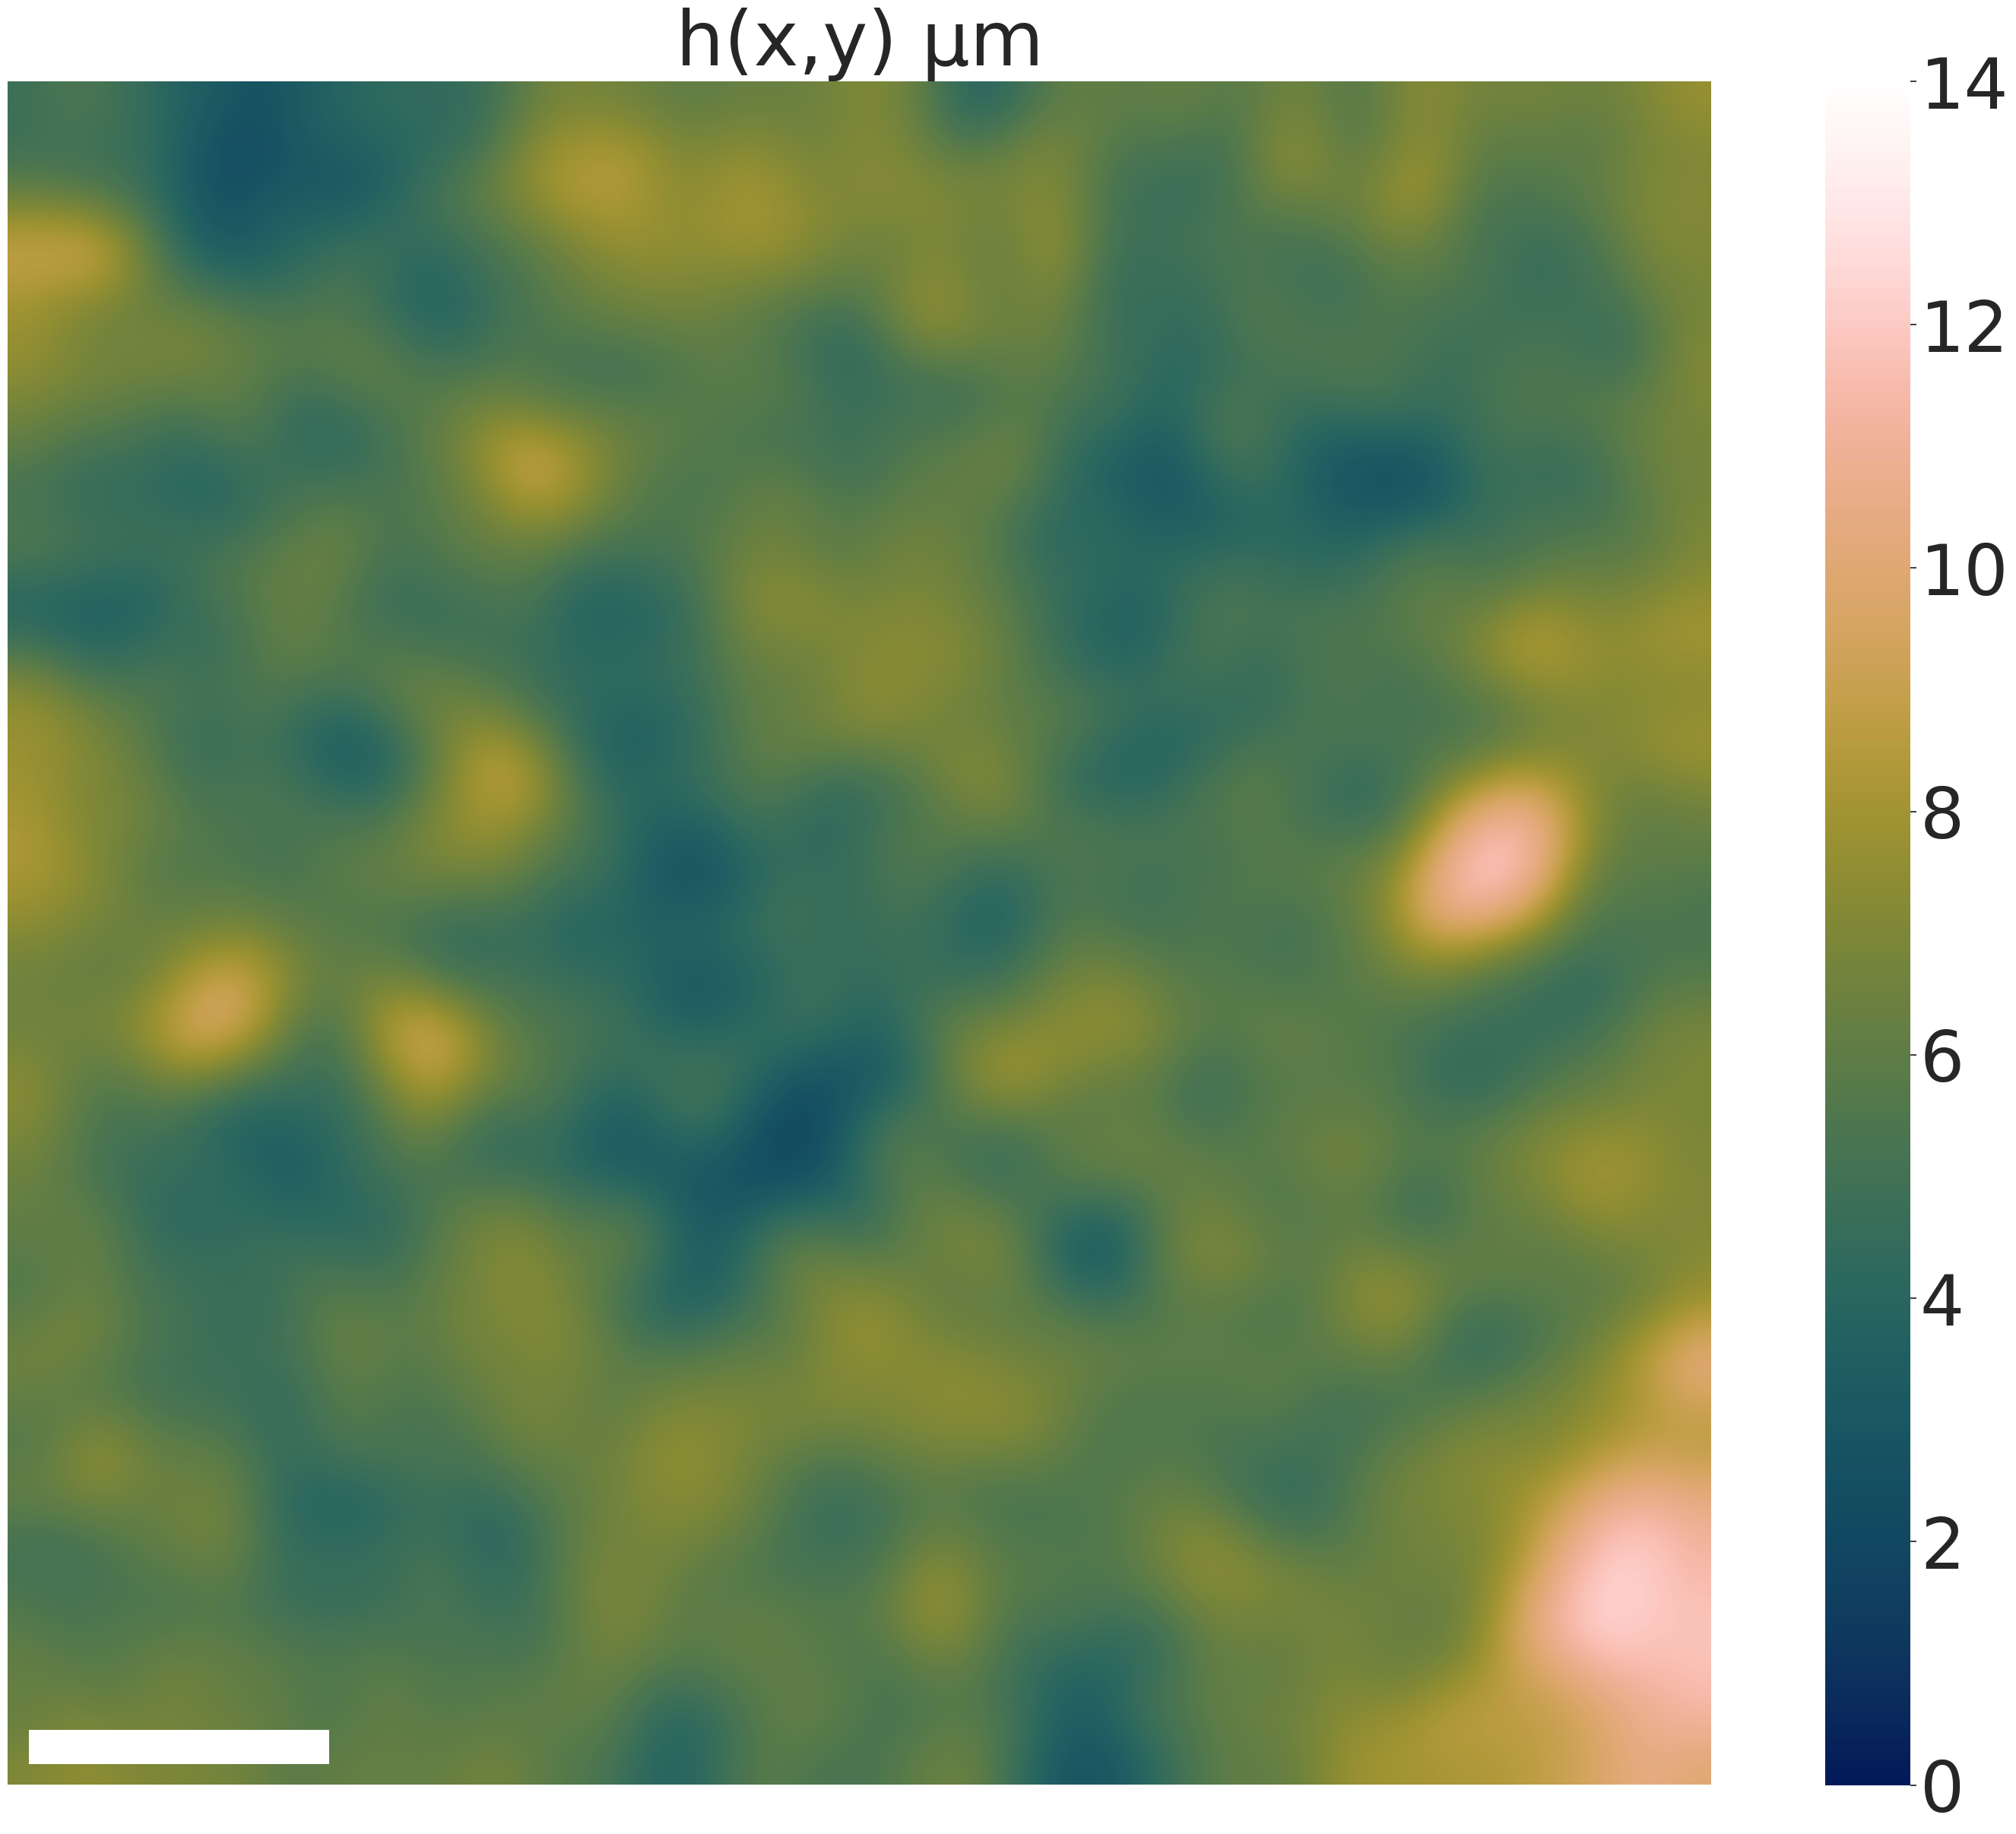

In [24]:
if param == "cd":
    vmin = 0.2
    vmax = -0.2
    cmap = "rocket"

if param == "h":
    vmin = 0
    vmax = 14
    cmap = cm.batlowW

fig, ax = plt.subplots(1,1, figsize=(32,26))
sns.set_theme(style='ticks', palette='bright', font_scale=6)

if measure == "disc":
    #im = (im_disc - n0) / (np.mean(im_disc) - n0) - 1
    im = im_disc
    sns.heatmap(im, square=True, cmap=cmap, xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)
else:
    sns.heatmap(h_im, square=True, cmap=cmap, xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)

sb = ScaleBar(microscope.pix_to_um, 'um', box_alpha=0, color="w", height_fraction=2e-2, scale_loc="none", fixed_value=100)
sb.location = 'lower left'
ax.add_artist(sb)

if param == "cd":
    ax.set(title=r"$c_d(r;x,y)/\bar{c}_d - 1$")
else:
    ax.set(title=rf"{param}(x,y) µm")

fig.tight_layout()

In [25]:
# Save figure
fig.savefig(f"figs/Elife/subfigures/{param}_{measure}wise_heatmap.png", dpi=100)

In [4]:
# # Path(f"figs/frames/field_refractive_index/{dataset}").mkdir(parents=True, exist_ok=True)


# for frame in range(31, 41):
#     im_pix = imageio.v2.imread(f"data/experimental/raw/{dataset}/{fname}_{frame}.tiff") * scaling

#     if param == "h":
#         im_pix = im_pix * gamma + delta

#     elif param == "c":
#         im_pix = (im_pix - n0) / (ncell - n0) - 1

#     elif param == "n":
#         #im_pix = im_pix / 10_000
#         im_pix = im_pix - np.mean(im_pix) +  1.38


#     if param == "n":
#         vmin = 1.37
#         vmax = 1.40
#         cmap = "rocket"

#     if param == "h":
#         vmin = 0
#         vmax = 8
#         cmap = cm.batlowW

#     fig, ax = plt.subplots(1,1, figsize=(32,18))

#     sns.set_theme(style='ticks', palette='bright', font_scale=4)
#     sns.heatmap(im_pix, square=True, cmap=cmap, xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)

#     sb = ScaleBar(pix_to_um[-1], 'um', box_alpha=0, color="w", height_fraction=2e-2, scale_loc="none", fixed_value=100)
#     sb.location = 'lower left'
#     ax.add_artist(sb)

#     if measure == "disc":
#         ax.set(title=r"$c_d/\bar{c}_d - 1$")
#     if param == "h":
#         ax.set(title=rf"{param}(x,y) µm,    t = {frame * 0.25:0.2f} h")

#     elif param == "n":
#         ax.set(title=rf"{param}(x,y),    t = {frame * 0.25:0.2f} h")

#     # fig.tight_layout()
#     fig.subplots_adjust(left=0.15, right=0.9, top=.95, bottom=0.02)
#     if param == "h":
#         fig.savefig(f"figs/frames/field_height/{dataset}/frame_{frame}.png", dpi=100)
#     elif param == "n" or param == "c":
#         fig.savefig(f"figs/frames/field_refractive_index/{dataset}/frame_{frame}.png", dpi=100)


In [1]:
# import matplotlib as mpl
# font  = {'size': 24}
# mpl.rc('font', **font)

# Path(f"figs/frames/3D_projection/").mkdir(parents=True, exist_ok=True)
# Path(f"figs/frames/3D_projection/{dataset}").mkdir(parents=True, exist_ok=True)

# cmap = cm.batlowW

# X, Y = np.meshgrid(np.arange(3648) * pix_to_um[1],
#                    np.arange(3648) * pix_to_um[1])

# for frame in range(0, 41):
#     im_pix = imageio.v2.imread(f"data/experimental/raw/{dataset}/{fname}_{frame}.tiff") * scaling
#     Z = im_pix * gamma + delta

#     fig, ax = plt.subplots(figsize=(32,18), subplot_kw={"projection": "3d"})

#     ax.set_box_aspect((np.ptp(X), np.ptp(Y), 9))  # aspect ratio is 1:1:1 in data space
#     ax.set(zlim=(0,9))
#     ax.set_zticks([])

#     ax.plot_surface(X, 
#                     Y, 
#                     Z,
#                     rstride=10,
#                     cstride=10,
#                     antialiased=True,
#                     linewidth=0, 
#                     cmap=cmap,
#                     vmin=0,
#                     vmax=12)
    

#     ax.set_xlabel(r"$x~(µm)$", fontsize=24, labelpad=50)
#     ax.set_ylabel(r"$y~(µm)$", fontsize=24, labelpad=50)

#     m = mpl.cm.ScalarMappable(cmap=cmap)
#     m.set_array(np.linspace(0, 8, 100))
#     cbar_ax = fig.add_axes([0.95, 0.15, 0.02, 0.7])
#     cbar = fig.colorbar(m, cax=cbar_ax)
#     cbar.set_label(label=r"$h ~(µm)$", fontsize=28)

#     # fig.tight_layout()
#     fig.subplots_adjust(left=-0.25, right=1.2, top=1.25, bottom=-0.25)
#     fig.savefig(f"figs/frames/3D_projection/{dataset}/frame_{frame}.png", dpi=100);
